### **ICESat数据处理**

In [ ]:
# mount on google drive
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


In [ ]:
# !pip install cartopy
# !pip install pyrsimg
# !apt-get install hdf5-tools


In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pyrsimg import readTiff, imgShow


In [ ]:
path_glah14 = 'data/laser/GLAH14_634_2111_003_0351_0_01_0001.H5'
path_rsimg = 'data/rsimg/s2_gla_region_20220707.tif'


In [ ]:
!h5ls $path_glah14
# !h5ls $path_glah14/Data_1HZ/Geolocation/i_track
# !h5ls $path_glah14/Data_40HZ/Elevation_Surfaces


ANCILLARY_DATA           Group
BROWSE                   Group
Data_1HZ                 Group
Data_40HZ                Group
METADATA                 Group


In [ ]:
vars_glah14 = {}
with h5py.File(path_glah14,'r') as glah14:
    vars_glah14['lat'] = glah14['Data_40HZ/Geolocation/d_lat'][:]
    vars_glah14['lon'] = glah14['Data_40HZ/Geolocation/d_lon'][:]
    vars_glah14['time'] = glah14['Data_40HZ/Time/d_UTCTime_40'][:]
    vars_glah14['elev'] = glah14['Data_40HZ/Elevation_Surfaces/d_elev'][:]
    ### saturation correction
    vars_glah14['satu_corr'] = glah14['Data_40HZ/Elevation_Corrections/d_satElevCorr'][:]
    vars_glah14['satu_flag'] = glah14['Data_40HZ/Quality/sat_corr_flg'][:]
    ### data filtering
    vars_glah14['elev_flg'] = glah14['Data_40HZ/Quality/elev_use_flg'][:]
    vars_glah14['att_flg'] = glah14['Data_40HZ/Quality/sigma_att_flg'][:]
    ### Delta Ellipsoid (T/P ellipsoid - wgs84 ellipsoid), the glah14 elevation is T/P ellipsoid-based.
    vars_glah14['delta_ellip'] = glah14['Data_40HZ/Geophysical/d_deltaEllip'][:]
    print(vars_glah14['lat'].shape)

## 2. remote sensing image
rsimg = readTiff(path_rsimg)


(1076400,)


### Remove outlier values

In [ ]:
ids = np.where((abs(vars_glah14['lat'])<90) \
                & (vars_glah14['lon']<360) \
                & (vars_glah14['lon']>0))
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)



(936728,)


### Filter out low-quality data

In [ ]:
ids = np.where((vars_glah14['elev_flg']==0) & vars_glah14['att_flg'] == 0)[0]
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)


(936728,)


### apply corrections

In [ ]:
### Apply saturation filtering and correction
ids = np.where(vars_glah14['satu_flag']<2)[0]
for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids]
print(vars_glah14['lat'].shape)
vars_glah14['elev_cor'] = vars_glah14['elev'] + vars_glah14['satu_corr']   ### saturation correction


(635138,)


In [ ]:
### Apply conversion from T/P ellipsoid to WGS84
vars_glah14['elev_cor'] = vars_glah14['elev_cor'] - vars_glah14['delta_ellip']


In [ ]:
ids_2 = np.where((vars_glah14['lat']>30.38) \
                 & (vars_glah14['lat']<30.77) \
                 & (vars_glah14['lon'] >94.56) \
                 & (vars_glah14['lon']<95.04))

for key in vars_glah14:
  vars_glah14[key] = vars_glah14[key][ids_2]
print(vars_glah14['lat'].shape)


(212,)


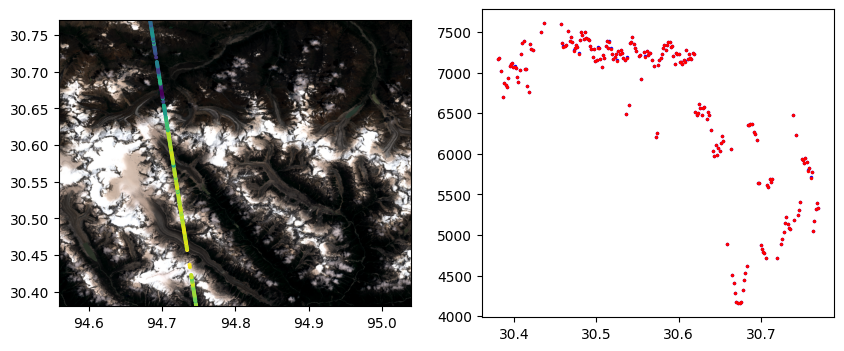

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=vars_glah14['lon'], y=vars_glah14['lat'], c=vars_glah14['elev_cor'], s=3.5)  ## jason data
ax[1].plot(vars_glah14['lat'], vars_glah14['elev'], 'b.', markersize = 3)
ax[1].plot(vars_glah14['lat'], vars_glah14['elev_cor'], 'r.', markersize = 3)
# ax[1].set_ylim(7200, 7300)
# ax[1].set_xlim(30.4, 30.6)


## write out to .h5 file.

In [ ]:
# file_out = 'data/laser/isat_gla_region.h5'
# with h5py.File(file_out, "w") as f_out:
#     [f_out.create_dataset(key, data=vars_glah14[key]) for key in vars_glah14.keys()]
#     print('written file:', (file_out))



written file: data/laser/isat_gla_region.h5
